In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator,img_to_array, load_img
from tensorflow.keras.applications import ResNet50,Xception
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Input, GlobalAveragePooling2D, Dense, Dropout, multiply, Reshape, Conv2D, Activation, Add, Dropout, GlobalAveragePooling2D, BatchNormalization, Multiply,MaxPooling2D,Concatenate,Conv2D, UpSampling2D, Cropping2D,Lambda
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler,ModelCheckpoint

import shutil
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.metrics import Accuracy


In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/DataSet_subclasses')
os.listdir('/content')

train_dataset_dir= "/content/drive/MyDrive/Data_Set_final/Treino"
#train_dataset_dir = "/content/drive/MyDrive/DataSet_minha_t/Teste"
Valid_dataset_dir= "/content/drive/MyDrive/Data_Set_final/Validacao"
# Valid_dataset_dir = "/content/drive/MyDrive/DataSet_minha_t/Validacao"
test_dataset_dir = '/content/drive/MyDrive/Data_Set_final/Teste'
# test_dataset_dir = "/content/drive/MyDrive/DataSet_minha_t/Teste"
print(len(os.listdir(train_dataset_dir)))
print(len(os.listdir(Valid_dataset_dir)))
print(len(os.listdir(test_dataset_dir)))


Mounted at /content/drive
3
3
3


In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [4]:
# Set the image size and batch size for training
batch_size =8

In [5]:
# Define input shape
input_shape = (400,400,3)


In [6]:
# Create the directories if they don't exist
import os

if not os.path.exists(train_dataset_dir):
    os.makedirs(train_dataset_dir)
    print(f"Created directory: {train_dataset_dir}")

if not os.path.exists(Valid_dataset_dir):
    os.makedirs(Valid_dataset_dir)
    print(f"Created directory: {Valid_dataset_dir}")

print("Please ensure your training and validation images are placed in these directories, organized into subfolders by class.")

Please ensure your training and validation images are placed in these directories, organized into subfolders by class.


In [7]:
# Data augmentation and normalization for training
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
)

In [8]:
# Load the training dataset with data augmentation
train_generator = train_datagen.flow_from_directory(
    train_dataset_dir,
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode='categorical',
    )

Found 2000 images belonging to 3 classes.


In [9]:
# Load the training dataset with data augmentation
train_generator = train_datagen.flow_from_directory(
    train_dataset_dir,
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode='categorical',
    )

Found 2000 images belonging to 3 classes.


In [10]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_data_generator = ImageDataGenerator(
    rescale=1.0/255.0,  # Normalize pixel values to the range [0, 1]
    # Add any other preprocessing options if needed
)

test_generator = test_data_generator.flow_from_directory(
    test_dataset_dir,
    target_size=(400,400),  # Adjust to match your model's input size
    batch_size=16,           # Adjust batch size as needed
    class_mode='categorical',  # If you have class labels
    shuffle=False              # Do not shuffle test data
)

Found 599 images belonging to 3 classes.


In [11]:

# Data normalization for validation and testing
val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

In [12]:
# Load the validation dataset
val_generator = val_datagen.flow_from_directory(
    Valid_dataset_dir,
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode='categorical'
)

Found 150 images belonging to 3 classes.


In [13]:
# Create an input layer
input_layer = Input(shape=input_shape)

In [14]:
import tensorflow_hub as hub

In [15]:
bit_l_url = "https://tfhub.dev/google/bit/m-r101x1/1"

In [16]:
# Load the BiT L model from TensorFlow Hub
bit_l_model = hub.KerasLayer(bit_l_url, trainable=True)
bit_l_output = tf.keras.layers.Lambda(lambda x: bit_l_model(x))(input_layer)

In [17]:
bit_l_output_reshaped = Reshape((1, 1, -1))(bit_l_output)  # Reshape to match the expected shape

In [18]:
# Load the Xception model without top classification layers
xception_base_model = Xception(weights='imagenet', include_top=False, input_shape=input_shape)
for layer in xception_base_model.layers:
    layer.trainable = True

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
# Connect the input layer to the base models
xception_features = xception_base_model(input_layer)


In [20]:
combined_features =multiply([xception_features,bit_l_output_reshaped])

In [21]:
# Apply Squeeze-and-Excitation block
def se_block(input_tensor):
    num_channels = input_tensor.shape[-1]

    # Squeeze operation (Global Average Pooling)
    squeeze = GlobalAveragePooling2D()(input_tensor)
    squeeze = Reshape((1, 1, num_channels))(squeeze)

    # Excitation operation (Fully connected layers)
    excitation = Dense(num_channels // 16, activation='relu')(squeeze)
    excitation = Dense(num_channels, activation='sigmoid')(excitation)

    # Scale the input feature maps
    scaled_features = multiply([input_tensor, excitation])

    return scaled_features

In [22]:
se_output = se_block(combined_features)


In [23]:
# Add a classification head to the combined features
from tensorflow.keras.regularizers import l2
x = tf.keras.layers.GlobalAveragePooling2D()(se_output)
x = tf.keras.layers.Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.1)(x)
x = tf.keras.layers.Dense(2048, activation='relu')(x)
x = tf.keras.layers.Dense(512, activation='selu',kernel_regularizer=l2(0.02))(x)
x = BatchNormalization()(x)
output = tf.keras.layers.Dense(3, activation='softmax')(x)  # 7output classes


In [24]:
# Create the ensemble model
model = Model(inputs=input_layer, outputs=output)

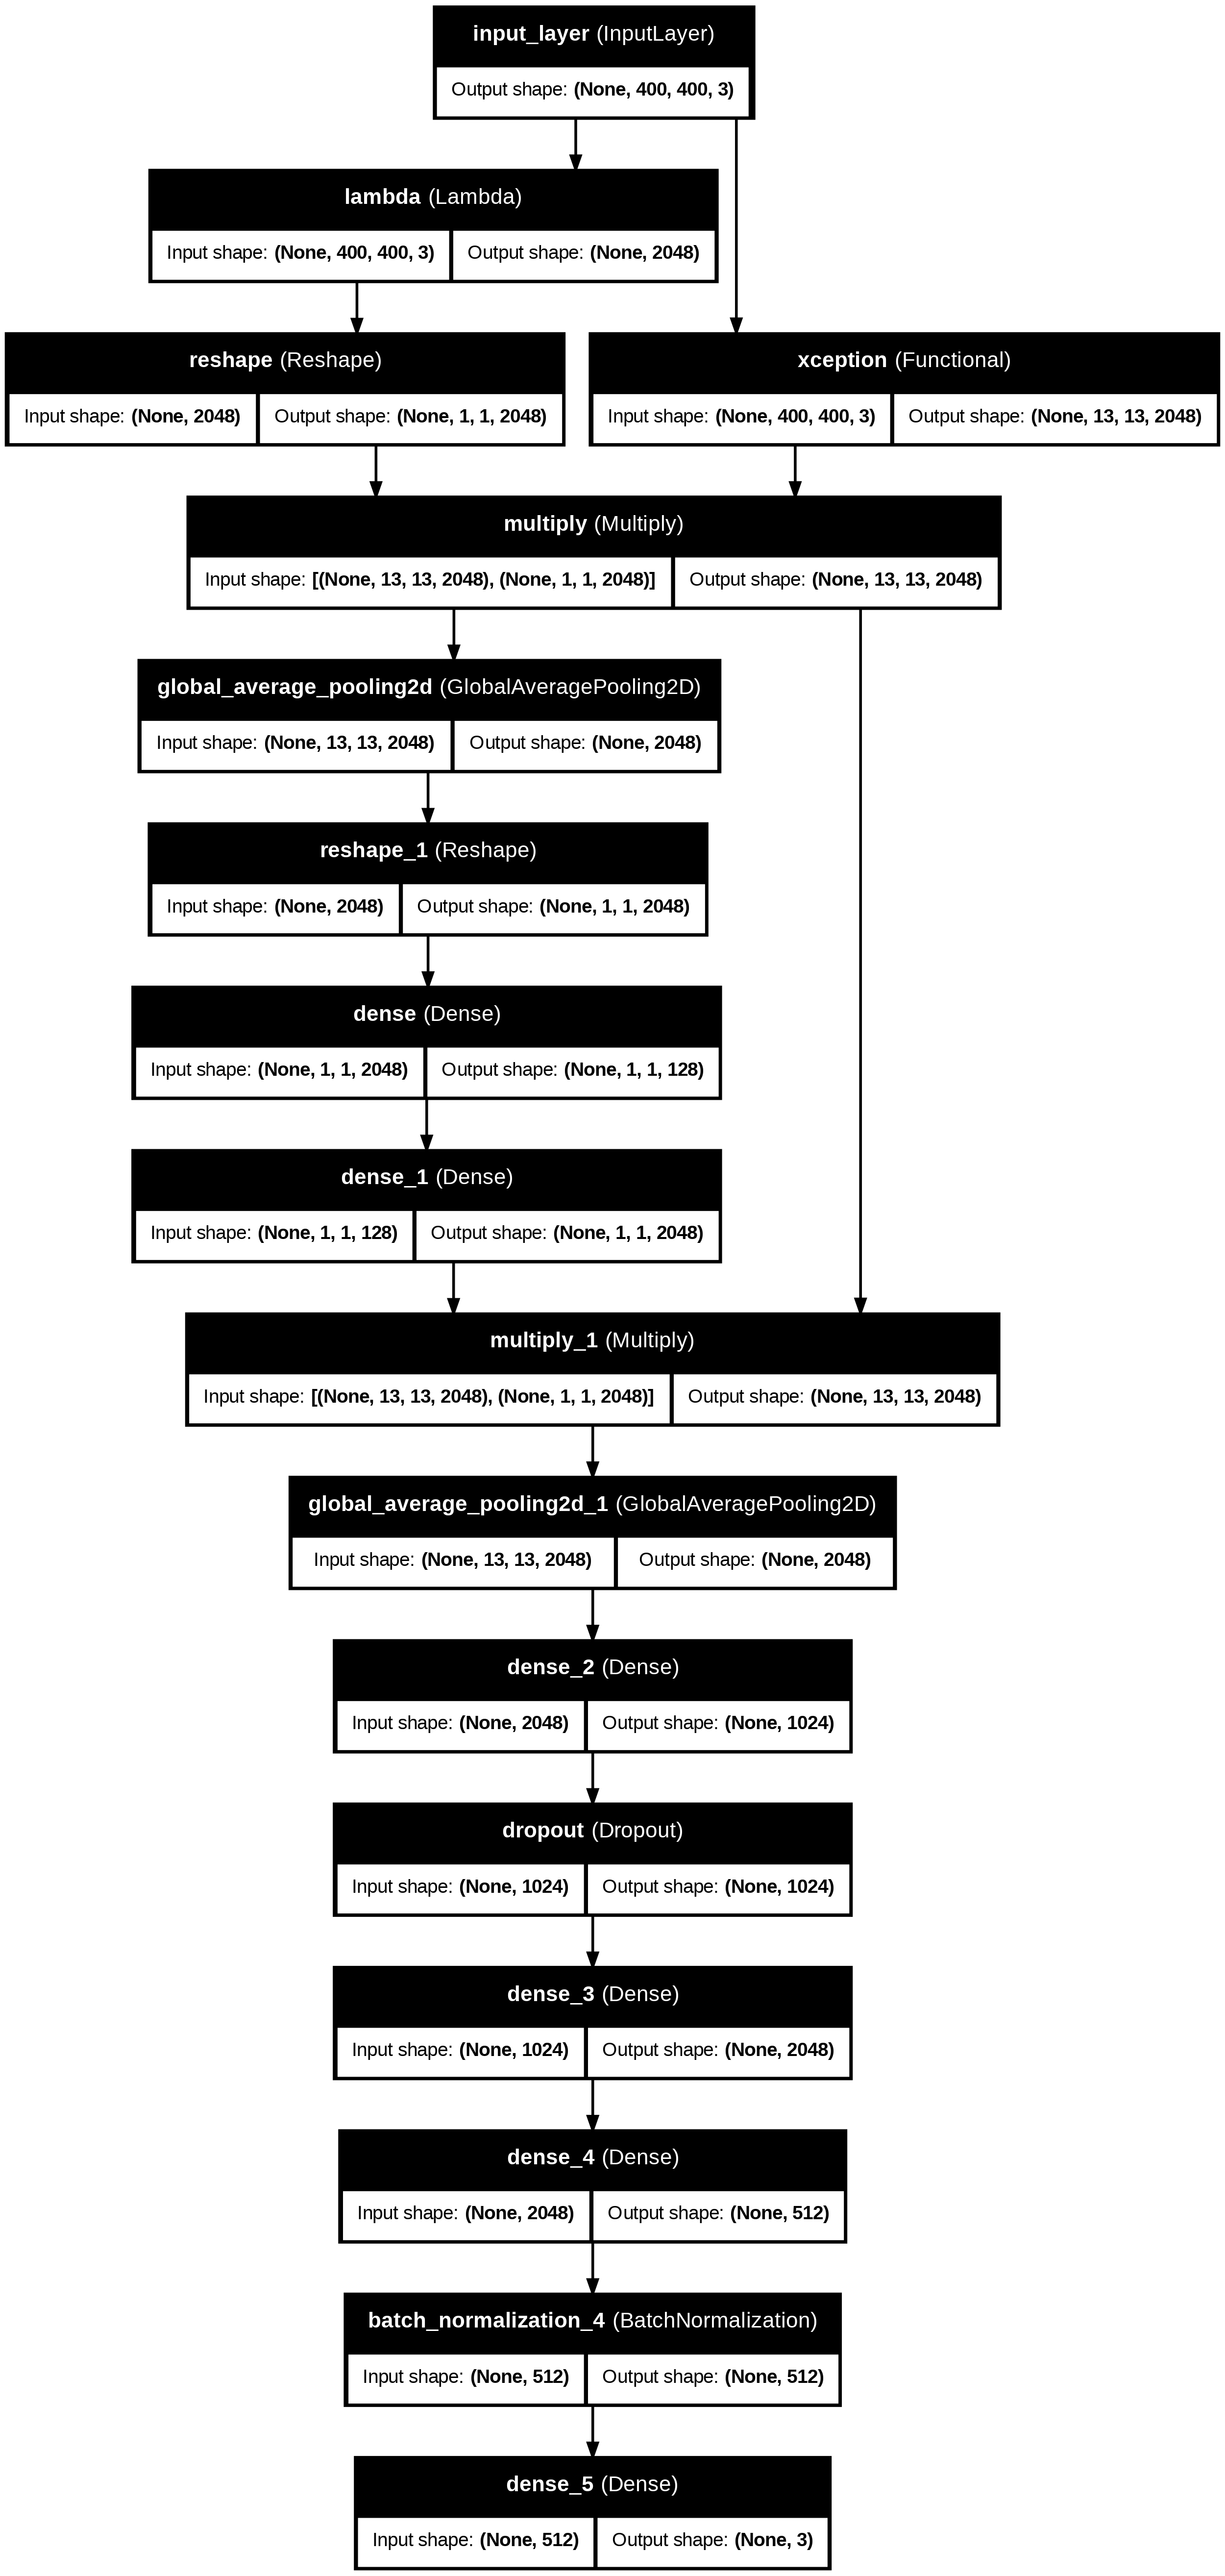

In [25]:
import tensorflow as tf
from tensorflow.keras.utils import plot_model

# Define your model here
model = model

# Specify the file path where you want to save the model architecture image
image_path = 'model_architecture.png'

# Plot the model architecture and save it as an image
plot_model(model, to_file=image_path, show_shapes=True, show_layer_names=True)

In [26]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 400, 400,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 2048)      │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception            │ (None, 13, 13,    │ 20,861,480 │ input_layer[0][0] │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1,      │          0 │ lambda[0][0]      │
│                     │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 13, 13,    │          0 │ xception[0][0],   │
│                     │ 2048)             │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 128) │    262,272 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1,      │    264,192 │ dense[0][0]       │
│                     │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 13, 13,    │          0 │ multiply[0][0],   │
│ (Multiply)          │ 2048)             │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ multiply_1[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1024)      │  2,098,176 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024)      │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2048)      │  2,099,200 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │  1,049,088 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │      1,539 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,637,995 (101.62 MB)

 Trainable params: 26,582,443 (101.40 MB)

 Non-trainable params: 55,552 (217.00 KB)

In [27]:
import tensorflow as tf
from tensorflow.keras.losses import categorical_crossentropy

def combined_loss(y_true, y_pred, alpha=0.2, categorical_weight=0.5):
    # Compute the categorical cross-entropy loss
    cat_loss = categorical_crossentropy(y_true, y_pred)

    # Reshape the inputs to get anchor, positive, and negative examples
    anchor = tf.reshape(y_pred[:, 0], shape=(-1, 1))
    positive = tf.reshape(y_pred[:, 1], shape=(-1, 1))
    negative = tf.reshape(y_pred[:, 2], shape=(-1, 1))

    # Compute the distance between the anchor and the positive
    pos_distance = tf.reduce_sum(tf.square(anchor - positive), axis=1)

    # Compute the distance between the anchor and the negative
    neg_distance = tf.reduce_sum(tf.square(anchor - negative), axis=1)

    # Compute the triplet loss
    triplet_basic_loss = pos_distance - neg_distance + alpha
    triplet_loss = tf.reduce_mean(tf.maximum(triplet_basic_loss, 0.0), axis=0)

    # Compute the combined loss
    combined_loss = categorical_weight * cat_loss + (1 - categorical_weight) * triplet_loss

    return combined_loss

# Example usage in a Keras model
model.compile(optimizer='adam', loss=combined_loss, metrics=['accuracy'])


In [28]:
# Implement learning rate scheduling
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=5, verbose=1)

In [29]:

# Define the model checkpoint callback to save the best weights
model_checkpoint = ModelCheckpoint('ISIC2017_Classification_contour_ensemble5.weights.h5', monitor='val_accuracy', save_best_only=True, save_weights_only=True, verbose=1)

In [30]:
# Implement early stopping
early_stopping = EarlyStopping(monitor='val_accuracy', patience=30, verbose=1, restore_best_weights=True)

In [31]:
# Train the model
epochs =15
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 32,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // 32,
    callbacks=[lr_scheduler,model_checkpoint,early_stopping]
)

Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 33s/step - accuracy: 0.4358 - loss: 24.4540 
Epoch 1: val_accuracy improved from None to 0.31250, saving model to ISIC2017_Classification_contour_ensemble5.weights.h5

Epoch 1: finished saving model to ISIC2017_Classification_contour_ensemble5.weights.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 2242s 35s/step - accuracy: 0.5202 - loss: 18.1667 - val_accuracy: 0.3125 - val_loss: 16.0940 - learning_rate: 0.0010
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 33s/step - accuracy: 0.6220 - loss: 7.1477 
Epoch 2: val_accuracy improved from 0.31250 to 0.40625, saving model to ISIC2017_Classification_contour_ensemble5.weights.h5

Epoch 2: finished saving model to ISIC2017_Classification_contour_ensemble5.weights.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 2172s 35s/step - accuracy: 0.5887 - loss: 5.7460 - val_accuracy: 0.4062 - val_loss: 4.0400 - learning_rate: 0.0010
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 33s/step - accuracy: 0.5643 - loss: 3.0225 
Epoch 3: val_accuracy did not impro

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 5: val_accuracy did not improve from 0.46875
62/62 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.7500 - loss: 1.1185 - val_accuracy: 0.4375 - val_loss: 2.9346 - learning_rate: 0.0010
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 33s/step - accuracy: 0.5948 - loss: 1.0434 
Epoch 6: val_accuracy improved from 0.46875 to 0.56250, saving model to ISIC2017_Classification_contour_ensemble5.weights.h5

Epoch 6: finished saving model to ISIC2017_Classification_contour_ensemble5.weights.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 2186s 35s/step - accuracy: 0.5665 - loss: 0.9871 - val_accuracy: 0.5625 - val_loss: 1.1083 - learning_rate: 0.0010
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 33s/step - accuracy: 0.6136 - loss: 0.8396 
Epoch 7: val_accuracy improved from 0.56250 to 0.59375, saving model to ISIC2017_Classification_contour_ensemble5.weights.h5

Epoch 7: finished saving model to ISIC2017_Classification_contour_ensemble5.weights.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 2181s 35s/step - accuracy: 0.6331 - loss: 0

In [32]:
print(f"Número de imagens no gerador de treinamento: {train_generator.samples}")
print(f"Número de imagens no gerador de validação: {val_generator.samples}")
print(f"Número de imagens no gerador de teste: {test_generator.samples}")

Número de imagens no gerador de treinamento: 2000
Número de imagens no gerador de validação: 150
Número de imagens no gerador de teste: 599


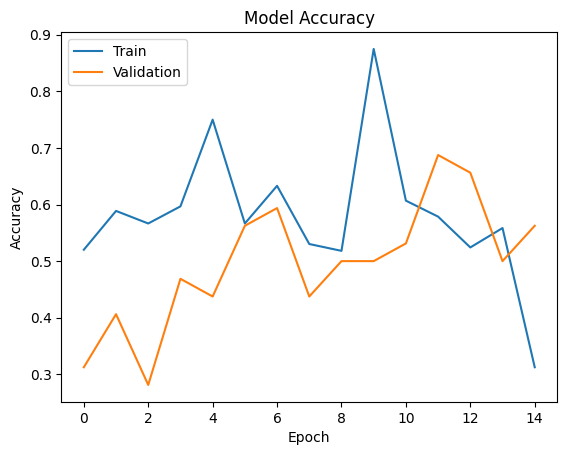

In [33]:
# Plot the training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

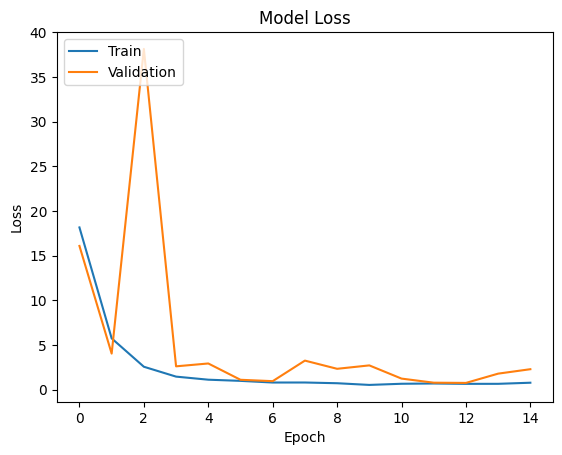

In [34]:
# Plot the training and validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [35]:
from tensorflow.keras.models import load_model

#Load the saved weights from the output directory in the executed model architecture .
model.load_weights('/content/ISIC2017_Classification_contour_ensemble5.weights.h5')

In [36]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


38/38 ━━━━━━━━━━━━━━━━━━━━ 1395s 37s/step - accuracy: 0.5910 - loss: 1.0203
Test Loss: 1.0202908515930176
Test Accuracy: 0.5909850001335144


38/38 ━━━━━━━━━━━━━━━━━━━━ 1411s 37s/step


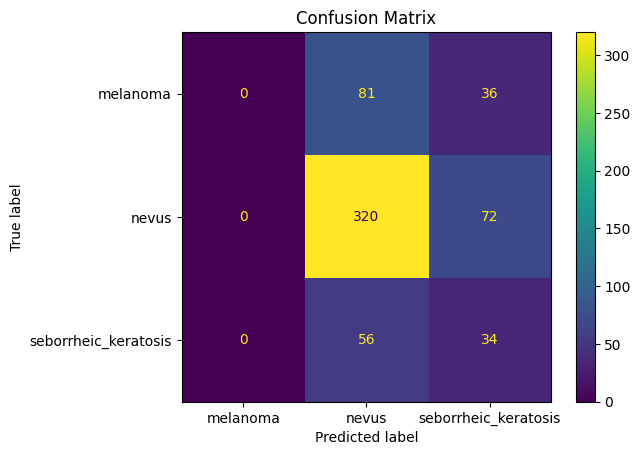

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#  the true labels and predicted labels for the test dataset
y_true = test_generator.classes
y_pred = model.predict(test_generator).argmax(axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap='viridis')
plt.title('Confusion Matrix')
plt.show()

In [38]:
labels = {0:'melanoma', 1:'nevus', 2:'seborrheic_keratosis'}


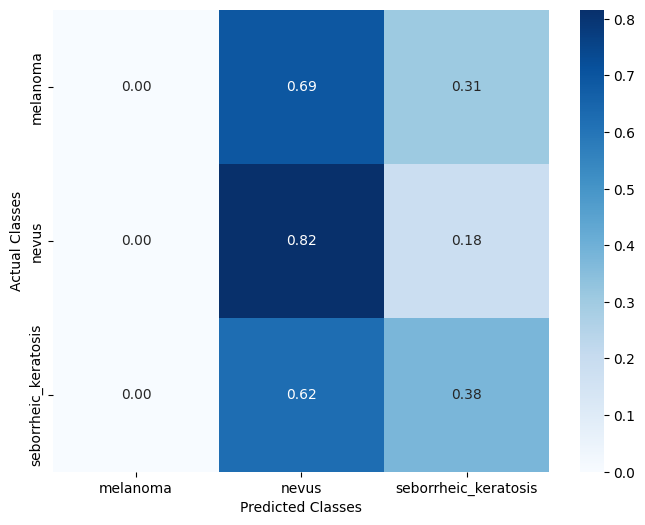

Confusion Matrix:
[[  0  81  36]
 [  0 320  72]
 [  0  56  34]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       117
           1       0.70      0.82      0.75       392
           2       0.24      0.38      0.29        90

    accuracy                           0.59       599
   macro avg       0.31      0.40      0.35       599
weighted avg       0.49      0.59      0.54       599



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
import seaborn as sns
from sklearn.metrics import classification_report
cm = confusion_matrix(y_true, y_pred)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cmn, annot=True, xticklabels=labels.values(), yticklabels=labels.values(),cmap=plt.cm.Blues, fmt='.2f')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show(block=False)

# Generate the classification report
report = classification_report(y_true, y_pred)

print("Confusion Matrix:")
print(cm)
print(report)

In [40]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
print("Precision: "+ str(precision_score(y_true, y_pred, average='weighted')))
print("Recall: "+ str(recall_score(y_true, y_pred, average='weighted')))
print("Accuracy: " + str(accuracy_score(y_true, y_pred)))
f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 Score: " + str(f1))


Precision: 0.4942154800999992
Recall: 0.5909849749582637
Accuracy: 0.5909849749582637
F1 Score: 0.5373621022921174


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
print("Precision: "+ str(precision_score(y_true, y_pred, average='macro')))
print("Recall: "+ str(recall_score(y_true, y_pred, average='macro')))
print("Accuracy: " + str(accuracy_score(y_true, y_pred)))
f1 = f1_score(y_true, y_pred, average='macro')
print("F1 Score: " + str(f1))


Precision: 0.3132184793663513
Recall: 0.3980347694633409
Accuracy: 0.5909849749582637
F1 Score: 0.3489771604186129


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [42]:
print("Precision: "+ str(precision_score(y_true, y_pred, average='micro')))
print("Recall: "+ str(recall_score(y_true, y_pred, average='micro')))
print("Accuracy: " + str(accuracy_score(y_true, y_pred)))
f1 = f1_score(y_true, y_pred, average='micro')
print("F1 Score: " + str(f1))


Precision: 0.5909849749582637
Recall: 0.5909849749582637
Accuracy: 0.5909849749582637
F1 Score: 0.5909849749582637


38/38 ━━━━━━━━━━━━━━━━━━━━ 1393s 37s/step


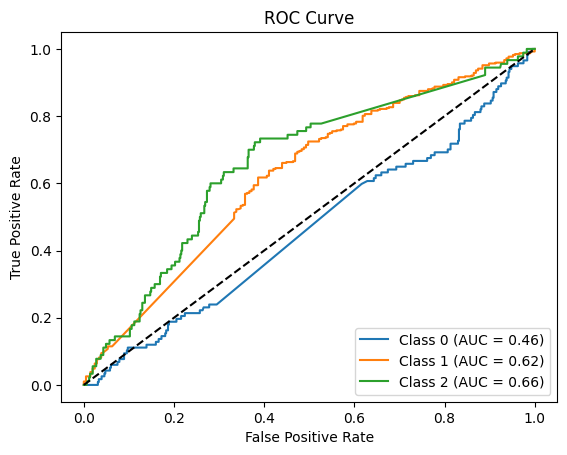

In [43]:
from sklearn.metrics import roc_curve, auc
y_true = test_generator.classes
# Get the probabilities for each class (0 and 1) from the model predictions
y_prob = model.predict(test_generator)

# Compute the ROC curve for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(train_generator.num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true == i, y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure()
for i in range(train_generator.num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [44]:
from sklearn.metrics import roc_auc_score
print("weighted Roc score: " + str(roc_auc_score(y_true,y_prob,multi_class='ovr',average='weighted')))
print("macro Roc score: " + str(roc_auc_score(y_true,y_prob,multi_class='ovr',average='macro')))
print("micro Roc score: " + str(roc_auc_score(y_true,y_prob,multi_class='ovr',average='micro')))

weighted Roc score: 0.598084487571461
macro Roc score: 0.5825442121039053
micro Roc score: 0.6860341805067434
